# Part 1 — Data Acquisition, Cleaning, and Exploratory Analysis

**Dataset:** Synthetic "Employee Health & Insurance Cost" dataset (`raw_data.csv`), 1540 rows × 9 columns, generated by `generate_raw_data.py`. Target variable: `annual_charges`.

This notebook performs all required cleaning, EDA, and visualization steps end-to-end. See `README.md` for full written interpretation of every finding (skewness, IQR outliers, scatter/box plot interpretation, heat map causal discussion, Spearman vs Pearson, and grouped aggregation).

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("plots", exist_ok=True)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## Task 1: Load and Inspect the Dataset

In [3]:
df = pd.read_csv("raw_data.csv")
print(df.head())

   age     sex    bmi  children smoker     region exercise_freq  prior_conditions annual_charges
0   48    male  38.64       NaN     no  northeast      moderate               1.0        4650.06
1   51  female  28.26       0.0     no  northwest           NaN               0.0         642.04
2   44  female  34.75       3.0     no  northwest           low               0.0        6130.97
3   43  female  24.74       0.0    yes  northeast      moderate               0.0       22027.02
4   31  female  35.76       2.0     no  northeast           NaN               1.0       $8132.21


In [4]:
print(df.dtypes)

age                   int64
sex                     str
bmi                 float64
children            float64
smoker                  str
region                  str
exercise_freq           str
prior_conditions    float64
annual_charges          str
dtype: object


In [5]:
print("Shape:", df.shape)

Shape: (1540, 9)


## Task 2: Null Value Analysis\n\nCompute count and percentage of missing values per column, report columns above the 20% threshold, and median-fill numeric columns below that threshold.

In [6]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / df.shape[0]) * 100
null_table = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct.round(2)})
print(null_table)

                  null_count  null_pct
age                        0      0.00
sex                        0      0.00
bmi                       94      6.10
children                  61      3.96
smoker                     0      0.00
region                     0      0.00
exercise_freq            386     25.06
prior_conditions         144      9.35
annual_charges             0      0.00


In [7]:
high_null_cols = null_table[null_table["null_pct"] > 20].index.tolist()
print(f"Columns exceeding 20% null rate: {high_null_cols}")

Columns exceeding 20% null rate: ['exercise_freq']


In [8]:
numeric_cols_with_nulls = [
    c for c in df.columns
    if c not in high_null_cols and df[c].dtype in ("float64", "int64") and df[c].isnull().sum() > 0
]
print(f"Numeric columns below 20% nulls to median-fill: {numeric_cols_with_nulls}")

for col in numeric_cols_with_nulls:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Filled '{col}' nulls with median = {median_val}")

Numeric columns below 20% nulls to median-fill: ['bmi', 'children', 'prior_conditions']
  Filled 'bmi' nulls with median = 29.08
  Filled 'children' nulls with median = 1.0
  Filled 'prior_conditions' nulls with median = 0.0


**Note:** `exercise_freq` exceeds the 20% null threshold and is categorical, not numeric — median-fill is undefined for categorical data. It is reported here but retained as-is with NaNs; it will be addressed via mode-fill or a dedicated "missing" category if used in Part 2 modeling. See README for the justification of median (vs. mean) imputation.

## Task 3: Duplicate Detection and Removal

In [9]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

Duplicate rows found: 40


In [10]:
null_pct_before = (df.isnull().sum() / df.shape[0] * 100).round(2)
df = df.drop_duplicates().reset_index(drop=True)
null_pct_after = (df.isnull().sum() / df.shape[0] * 100).round(2)

print(f"Rows removed: {n_dupes}. New shape: {df.shape}")

change_table = pd.DataFrame({"null_pct_before": null_pct_before, "null_pct_after": null_pct_after})
change_table["changed"] = change_table["null_pct_before"] != change_table["null_pct_after"]
print(change_table)

Rows removed: 40. New shape: (1500, 9)
                  null_pct_before  null_pct_after  changed
age                          0.00             0.0    False
sex                          0.00             0.0    False
bmi                          0.00             0.0    False
children                     0.00             0.0    False
smoker                       0.00             0.0    False
region                       0.00             0.0    False
exercise_freq               25.06            25.0     True
prior_conditions             0.00             0.0    False
annual_charges               0.00             0.0    False


## Task 4: Data Type Correction\n\n`annual_charges` was loaded as `object` dtype because some rows have a stray `$` prefix. We clean and convert it to numeric, and convert repetitive string columns to `category` dtype.

In [11]:
mem_before = df.memory_usage(deep=True).sum()
print(f"Memory usage BEFORE conversion: {mem_before:,} bytes")
print(f"'annual_charges' dtype before fix: {df['annual_charges'].dtype}")

Memory usage BEFORE conversion: 507,045 bytes
'annual_charges' dtype before fix: str


In [12]:
df["annual_charges"] = df["annual_charges"].astype(str).str.replace("$", "", regex=False)
df["annual_charges"] = pd.to_numeric(df["annual_charges"], errors="coerce")
print(f"'annual_charges' dtype after fix: {df['annual_charges'].dtype}")
print(f"Nulls introduced by coercion (should be 0): {df['annual_charges'].isnull().sum()}")

'annual_charges' dtype after fix: float64
Nulls introduced by coercion (should be 0): 0


In [13]:
for col in ["sex", "smoker", "region", "exercise_freq"]:
    df[col] = df[col].astype("category")

mem_after = df.memory_usage(deep=True).sum()
print(f"Memory usage AFTER conversion: {mem_after:,} bytes")
print(f"Memory reduction: {mem_before - mem_after:,} bytes ({(1 - mem_after/mem_before)*100:.1f}% smaller)")

Memory usage AFTER conversion: 66,882 bytes
Memory reduction: 440,163 bytes (86.8% smaller)


## Task 5: Descriptive Statistics and Skewness

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print(df[numeric_cols].describe())

Numeric columns: ['age', 'bmi', 'children', 'prior_conditions', 'annual_charges']
               age          bmi     children  prior_conditions  annual_charges
count  1500.000000  1500.000000  1500.000000       1500.000000     1500.000000
mean     41.222000    29.090300     1.138667          0.531333    11006.902593
std      13.569997     5.904688     1.242766          0.751040    10481.959112
min      18.000000    14.000000     0.000000          0.000000      500.000000
25%      30.000000    25.225000     0.000000          0.000000     4629.110000
50%      41.000000    29.080000     1.000000          0.000000     6820.670000
75%      53.000000    32.910000     2.000000          1.000000    12475.430000
max      64.000000    52.220000     5.000000          5.000000    81049.640000


In [15]:
skew_table = df[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print(skew_table)

most_skewed_col = skew_table.index[0]
print(f"\nMost skewed column: '{most_skewed_col}' (skew = {skew_table.iloc[0]:.3f})")

annual_charges      2.376263
prior_conditions    1.501509
children            1.053433
bmi                 0.039562
age                -0.028123
dtype: float64

Most skewed column: 'annual_charges' (skew = 2.376)


## Task 6: Outlier Detection with IQR\n\nApplied to `annual_charges` (the target, and most skewed column) and `bmi`. Outliers are documented, not dropped (see README for handling strategy in Part 2).

In [16]:
iqr_cols = ["annual_charges", "bmi"]
outlier_summary = {}
for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower_bound": lower, "upper_bound": upper,
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2),
    }
    print(f"{col}:")
    for k, v in outlier_summary[col].items():
        print(f"  {k}: {v}")
    print()

annual_charges:
  Q1: 4629.11
  Q3: 12475.43
  IQR: 7846.320000000001
  lower_bound: -7140.370000000002
  upper_bound: 24244.910000000003
  n_outliers: 173
  pct_outliers: 11.53

bmi:
  Q1: 25.225
  Q3: 32.91
  IQR: 7.684999999999995
  lower_bound: 13.697500000000009
  upper_bound: 44.437499999999986
  n_outliers: 8
  pct_outliers: 0.53



## Task 7: Visualizations

### 7a. Line Plot

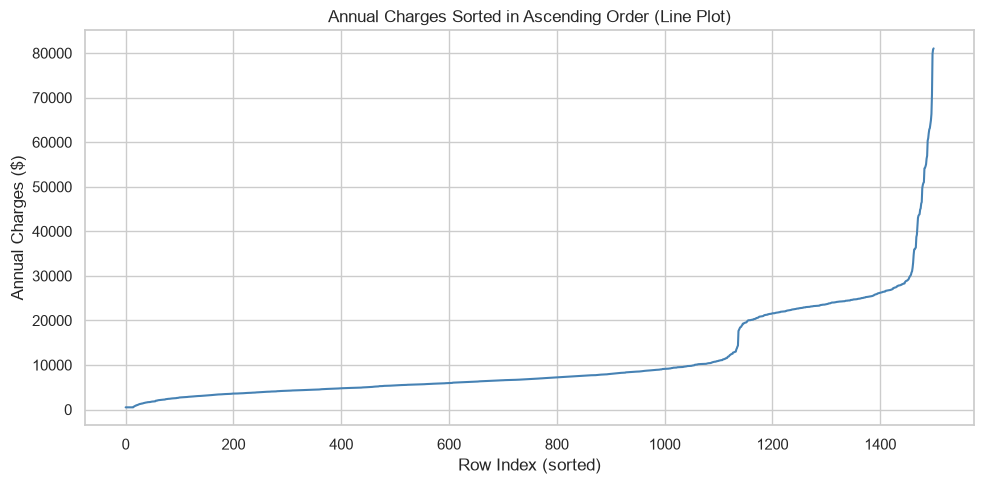

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["annual_charges"].sort_values().reset_index(drop=True), color="steelblue")
plt.title("Annual Charges Sorted in Ascending Order (Line Plot)")
plt.xlabel("Row Index (sorted)")
plt.ylabel("Annual Charges ($)")
plt.tight_layout()
plt.savefig("plots/01_line_plot_charges.png", dpi=120)
plt.show()

### 7b. Bar Chart — Mean Charges by Region

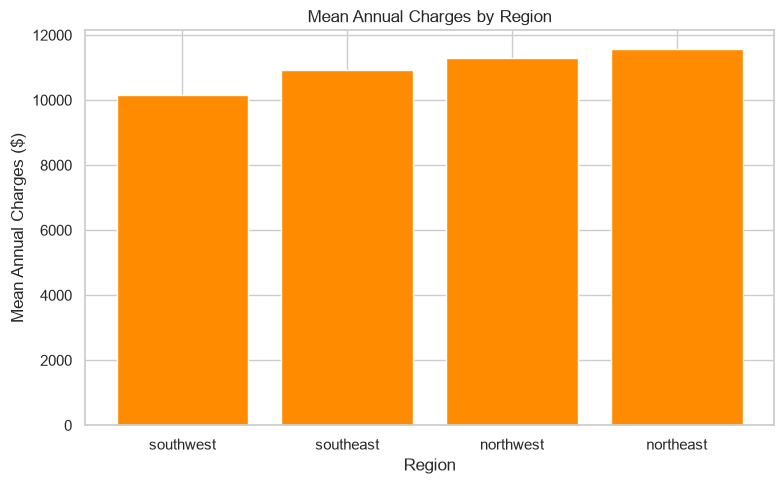

In [18]:
plt.figure(figsize=(8, 5))
region_means = df.groupby("region", observed=True)["annual_charges"].mean().sort_values()
plt.bar(region_means.index.astype(str), region_means.values, color="darkorange")
plt.title("Mean Annual Charges by Region")
plt.xlabel("Region")
plt.ylabel("Mean Annual Charges ($)")
plt.tight_layout()
plt.savefig("plots/02_bar_mean_charges_by_region.png", dpi=120)
plt.show()

### 7c. Histogram of Most Skewed Column

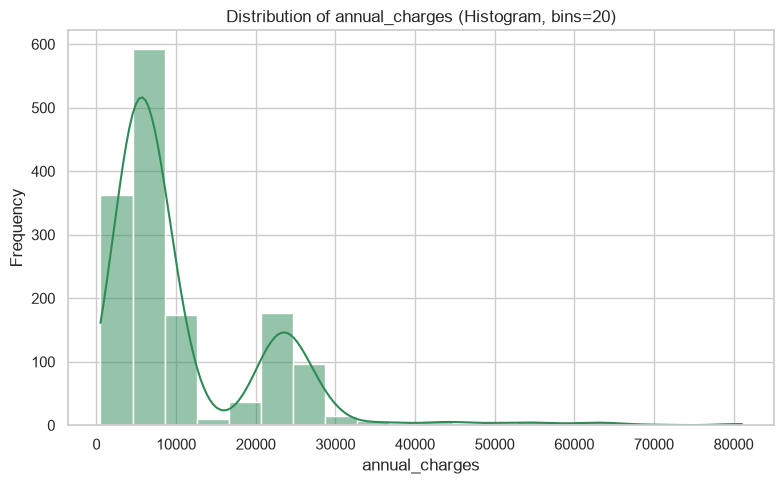

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df[most_skewed_col].dropna(), bins=20, kde=True, color="seagreen")
plt.title(f"Distribution of {most_skewed_col} (Histogram, bins=20)")
plt.xlabel(most_skewed_col)
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/03_histogram_most_skewed.png", dpi=120)
plt.show()

### 7d. Scatter Plot — BMI vs Annual Charges

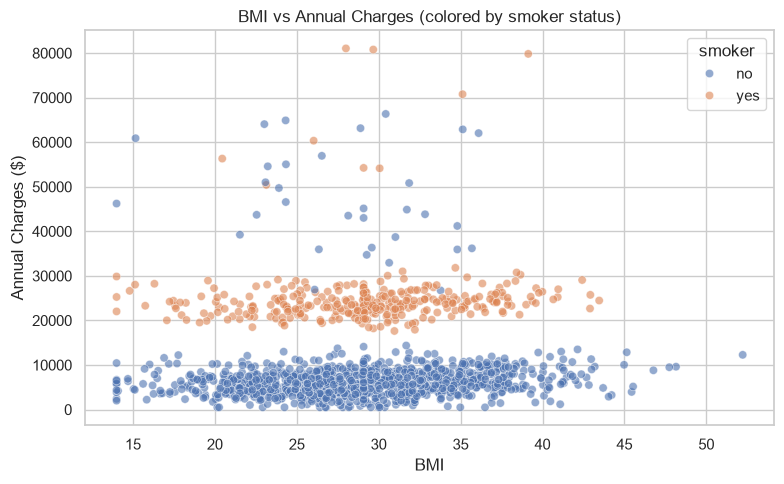

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="annual_charges", hue="smoker", alpha=0.6)
plt.title("BMI vs Annual Charges (colored by smoker status)")
plt.xlabel("BMI")
plt.ylabel("Annual Charges ($)")
plt.tight_layout()
plt.savefig("plots/04_scatter_bmi_vs_charges.png", dpi=120)
plt.show()

### 7e. Box Plot — Annual Charges by Smoker Status

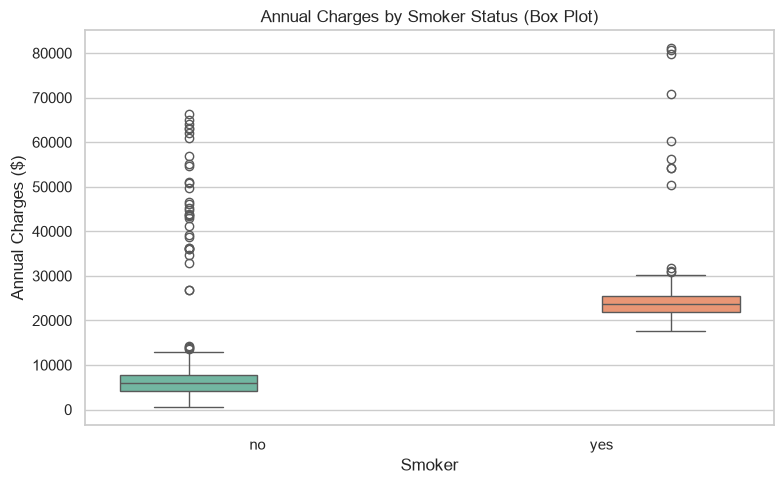

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="annual_charges", hue="smoker", palette="Set2", legend=False)
plt.title("Annual Charges by Smoker Status (Box Plot)")
plt.xlabel("Smoker")
plt.ylabel("Annual Charges ($)")
plt.tight_layout()
plt.savefig("plots/05_boxplot_charges_by_smoker.png", dpi=120)
plt.show()

### 7f. Correlation Heat Map (Pearson)

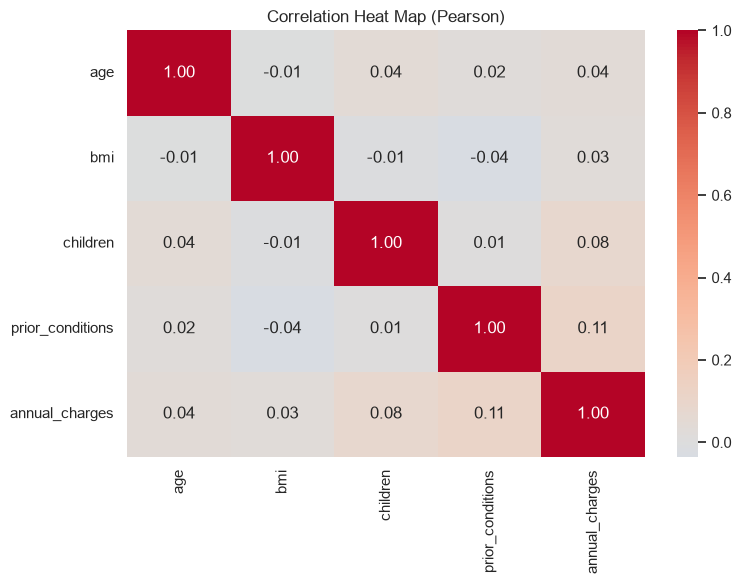

In [22]:
plt.figure(figsize=(8, 6))
pearson_corr = df[numeric_cols].corr(method="pearson")
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heat Map (Pearson)")
plt.tight_layout()
plt.savefig("plots/06_correlation_heatmap_pearson.png", dpi=120)
plt.show()

In [23]:
corr_unstacked = pearson_corr.where(~np.eye(len(pearson_corr), dtype=bool)).unstack().dropna()
corr_unstacked = corr_unstacked.reindex(corr_unstacked.abs().sort_values(ascending=False).index)
top_pair = corr_unstacked.index[0]
print(f"Highest |correlation| pair: {top_pair} -> {corr_unstacked.iloc[0]:.3f}")

Highest |correlation| pair: ('prior_conditions', 'annual_charges') -> 0.114


## Task 8a: Imputation Strategy Comparison (Mean vs Median)\n\nFor the two most-skewed numeric columns, compute both mean and median before imputation, then impute remaining nulls using the chosen strategy (median — see README for justification).

In [24]:
top2_skew_cols = skew_table.index[:2].tolist()
print(f"Two most-skewed numeric columns: {top2_skew_cols}")

for col in top2_skew_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"\n{col}: mean = {mean_val:.3f} | median = {median_val:.3f}")
    n_before = df[col].isnull().sum()
    if n_before > 0:
        df[col] = df[col].fillna(median_val)
        print(f"  Filled {n_before} remaining nulls in '{col}' with median.")
    n_after = df[col].isnull().sum()
    print(f"  isnull().sum() after imputation: {n_after}")

Two most-skewed numeric columns: ['annual_charges', 'prior_conditions']

annual_charges: mean = 11006.903 | median = 6820.670
  isnull().sum() after imputation: 0

prior_conditions: mean = 0.531 | median = 0.000
  isnull().sum() after imputation: 0


## Task 8b: Spearman Rank Correlation vs Pearson

In [25]:
spearman_corr = df[numeric_cols].corr(method="spearman")
print("Pearson matrix:")
print(pearson_corr.round(3))
print("\nSpearman matrix:")
print(spearman_corr.round(3))

Pearson matrix:
                    age    bmi  children  prior_conditions  annual_charges
age               1.000 -0.006     0.044             0.023           0.038
bmi              -0.006  1.000    -0.013            -0.035           0.032
children          0.044 -0.013     1.000             0.007           0.084
prior_conditions  0.023 -0.035     0.007             1.000           0.114
annual_charges    0.038  0.032     0.084             0.114           1.000

Spearman matrix:
                    age    bmi  children  prior_conditions  annual_charges
age               1.000 -0.005     0.052             0.026           0.133
bmi              -0.005  1.000    -0.002             0.000           0.131
children          0.052 -0.002     1.000            -0.001           0.147
prior_conditions  0.026  0.000    -0.001             1.000           0.283
annual_charges    0.133  0.131     0.147             0.283           1.000


In [26]:
diff = (spearman_corr - pearson_corr).abs()
diff_unstacked = diff.where(~np.eye(len(diff), dtype=bool)).unstack().dropna()
diff_unstacked = diff_unstacked.sort_values(ascending=False)

seen = set()
top3_pairs = []
for (a, b), val in diff_unstacked.items():
    key = frozenset([a, b])
    if key not in seen:
        seen.add(key)
        top3_pairs.append((a, b, val))
    if len(top3_pairs) == 3:
        break

diff_table = pd.DataFrame(top3_pairs, columns=["col_a", "col_b", "abs_diff"])
diff_table["pearson"] = [pearson_corr.loc[a, b] for a, b, _ in top3_pairs]
diff_table["spearman"] = [spearman_corr.loc[a, b] for a, b, _ in top3_pairs]
print("Top 3 pairs by |Spearman - Pearson|:")
print(diff_table)

Top 3 pairs by |Spearman - Pearson|:
              col_a           col_b  abs_diff   pearson  spearman
0  prior_conditions  annual_charges  0.168677  0.114481  0.283158
1    annual_charges             bmi  0.098781  0.032164  0.130945
2    annual_charges             age  0.095723  0.037758  0.133482


## Task 8c: Grouped Aggregation

In [27]:
group_agg = df.groupby("region", observed=True)["annual_charges"].agg(["mean", "std", "count"])
print(group_agg)

                   mean           std  count
region                                      
northeast  11562.971418  10285.693098    416
northwest  11293.458529  11217.350069    340
southeast  10911.839323  11073.186246    399
southwest  10163.936203   9170.530731    345


In [28]:
highest_mean_group = group_agg["mean"].idxmax()
highest_std_group = group_agg["std"].idxmax()
mean_ratio = group_agg["mean"].max() / group_agg["mean"].min()
print(f"Highest mean group: {highest_mean_group}")
print(f"Highest std group: {highest_std_group}")
print(f"Ratio of highest to lowest group mean: {mean_ratio:.3f}")

Highest mean group: northeast
Highest std group: northwest
Ratio of highest to lowest group mean: 1.138


## Save Cleaned Dataset\n\nThis `cleaned_data.csv` is used as the input for Part 2 (ML) and Part 3 (LLM integration).

In [29]:
df.to_csv("cleaned_data.csv", index=False)
print(f"cleaned_data.csv saved. Final shape: {df.shape}")
print("\nRemaining nulls per column (exercise_freq intentionally retains NaNs per the >20% rule):")
print(df.isnull().sum())

cleaned_data.csv saved. Final shape: (1500, 9)

Remaining nulls per column (exercise_freq intentionally retains NaNs per the >20% rule):
age                   0
sex                   0
bmi                   0
children              0
smoker                0
region                0
exercise_freq       375
prior_conditions      0
annual_charges        0
dtype: int64
